In [29]:
gdf.total_bounds

array([ 692405.38806786, 6166404.72204552,  695692.80139188,
       6169030.62220711])

   Zone key  Year                Type   ID  \
0         Y  2025           Volunteer    0   
1         Y  2025           Volunteer    1   
2         Y  2025           Volunteer    2   
3         Y  2025           Volunteer    3   
4         Z  2025           Volunteer    4   
..      ...   ...                 ...  ...   
88     Park  2025    Park_n_pay_south  109   
89     Park  2025     Park_n_pay_west  110   
90        R  2025          Restricted  113   
91     Park  2025  Restricted_parking  114   
92        R  2025      Restricted_HHX  114   

                                             geometry  
0   POLYGON ((692687.648 6168230.957, 692686.594 6...  
1   POLYGON ((692712.584 6168110.94, 692847.84 616...  
2   POLYGON ((692707.124 6167955.527, 692849.162 6...  
3   POLYGON ((692686.601 6167807.271, 692841.473 6...  
4   POLYGON ((692870.122 6167766.292, 692873.116 6...  
..                                                ...  
88  POLYGON ((695135.564 6166549.898, 694878.353 6...  

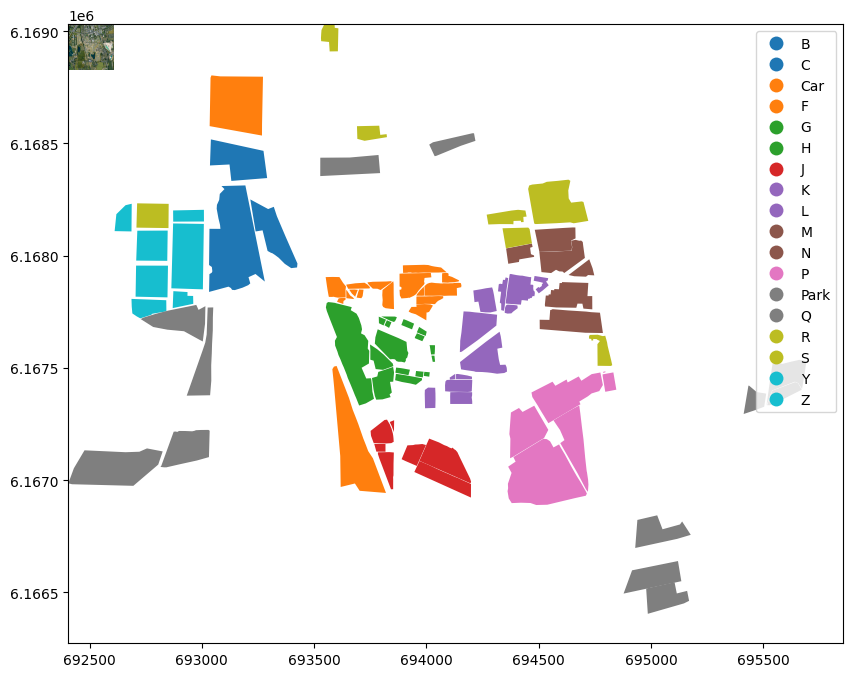

In [ ]:
import matplotlib.pyplot as plt 
import geopandas as gpd 
import rasterio 
from rasterio.plot import show 
from rasterio.windows import from_bounds 
#from shapely.geometry import box 

with rasterio.open('../data/2025-07-02-Roskilde-Festival_20cm.tif') as src:
    raster_crs = src.crs 
    fig, ax = plt.subplots(figsize=(10, 10))
    gdf = gpd.read_file("../data/camping_zones.shp")
    gdf = gdf.to_crs(raster_crs)
    print(gdf)
    minx, miny, maxx, maxy = gdf.total_bounds
 #   bbox = box(minx,miny,maxx,maxy)
  #  gdf_clipped = gdf.clip(bbox) 

    window = from_bounds(minx,miny,maxx,maxy, transform=src.transform) #left, bottom, right, top
    show(src.read(
            window=window,
            out_shape=(src.count, 1024, 1024)
        ), 
        transform=src.window_transform(window),  #not pixel-land, be coordinate land 
        ax=ax
    )

    gdf.plot(column="Zone key", legend=True, ax=ax) 
    plt.show()
    #TODO: I think downsampling without transform will give wrong alignment. We need to scale the window transform with Affine.scale or similar. 

    """from affine import Affine

data = src.read(
    window=window,
    out_shape=(src.count, 1024, 1024)
)

# Original transform for the window
transform = src.window_transform(window)

# Compute scaling factors
scale_x = window.width / 1024
scale_y = window.height / 1024

# Adjust transform
new_transform = transform * Affine.scale(scale_x, scale_y)

show(data, transform=new_transform, ax=ax)"""

<Axes: >

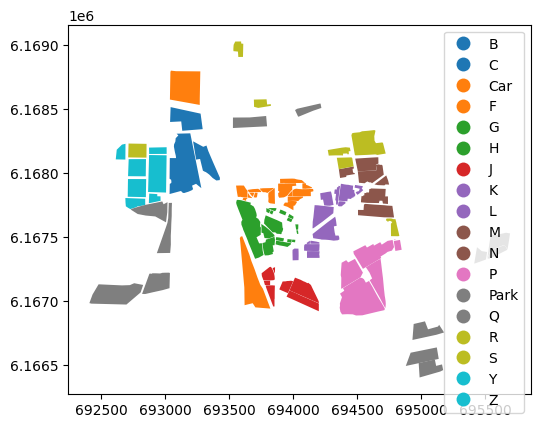

In [39]:
gdf.plot(column="Zone key", legend=True)

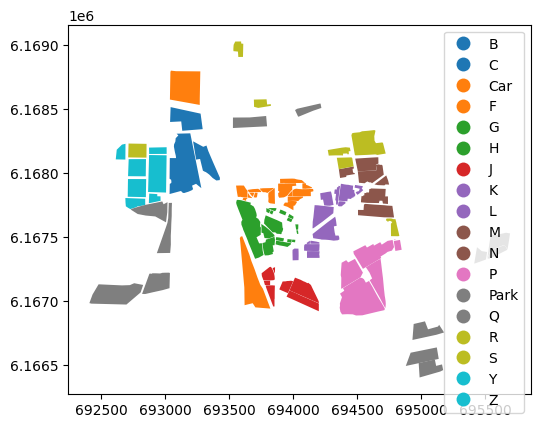

                                                   geometry  Year  \
Zone key                                                            
B         POLYGON ((693040.291 6168517.684, 693274.523 6...  2025   
C         MULTIPOLYGON (((693280.439 6167884.483, 693238...  2025   
Car       MULTIPOLYGON (((693600.104 6167508.631, 693655...  2025   
F         MULTIPOLYGON (((693640.716 6167810.032, 693639...  2025   
G         MULTIPOLYGON (((693785.89 6167482.089, 693810....  2025   
H         MULTIPOLYGON (((694028.295 6167526.931, 694022...  2025   
J         MULTIPOLYGON (((693979.496 6167081.165, 694020...  2025   
K         MULTIPOLYGON (((694175.231 6167392.015, 694203...  2025   
L         MULTIPOLYGON (((694264.274 6167615.512, 694326...  2025   
M         MULTIPOLYGON (((694740.196 6167943.676, 694747...  2025   
N         MULTIPOLYGON (((694504.666 6167714.401, 694548...  2025   
P         MULTIPOLYGON (((694536.695 6167182.553, 694550...  2025   
Park      MULTIPOLYGON (((695120.6

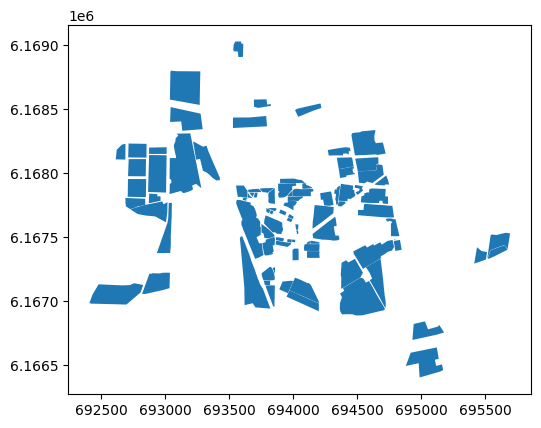

In [ ]:

unique_zones = gdf["Zone key"].unique()
merged_zones = gdf.dissolve(by="Zone key")
print(merged_zones)
merged_zones.plot(legend=True)
plt.show()
#for zone in unique_zones: #handle a merge

<Axes: >

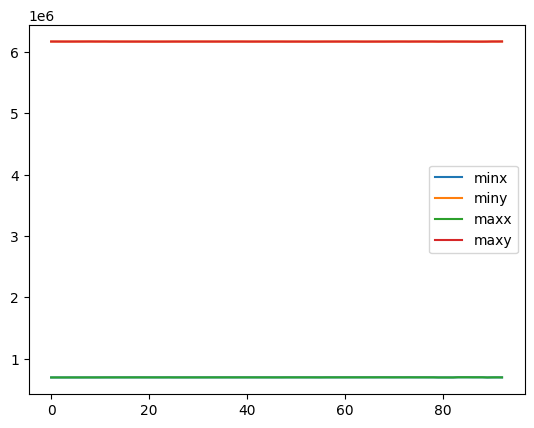

In [18]:
gdf.bounds.plot()